In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i : s for s, i in stoi.items()}
vocab_size = len(itos)
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [5]:
# build dataset
block_size = 3

def build_dataset(words):
    X, Y = [], []
    for w in words:
        # print(w)
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            # print(''.join(itos[i] for i in context), '--->', itos[ix])
            context = context[1:] + [ix] # crop and append

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

In [6]:
import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [7]:
n_embd = 10
n_hidden = 200

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd),           generator=g)
W1 = torch.randn(n_embd * block_size, n_hidden, generator=g) * (5/3) / ((block_size * n_embd) **0.5) # Tanh non-linearity Gain
# b1 = torch.randn(n_hidden,                      generator=g) * 0.01
W2 = torch.randn(n_hidden, vocab_size,          generator=g) * 0.01
b2 = torch.randn(vocab_size,                    generator=g) * 0

    
bngain = torch.ones((1, n_hidden)) # BN scaling 
bnbias = torch.zeros((1, n_hidden)) # BN shifting
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1 ,W2, b2, bngain, bnbias]
sum(p.nelement() for p in parameters)
for p in parameters:
    p.requires_grad = True



In [9]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    ix = torch.randint(0, Xtr.shape[0], (batch_size, ), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]


    # forward pass
    emb = C[Xb] # embedding
    embcat = emb.view(emb.shape[0], -1) # vector concatenation
    # Linear Layer
    hpreact = embcat @ W1# + b1          # hidden layer pre-activation

    # BATCH NORM LAYER
    # --------------------------------------------------------------------------------
    bnmeani = hpreact.mean(0, keepdim=True)
    bnstdi = hpreact.std(0, keepdim=True)
    hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias # Batch Normalization

    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
        bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi
    
    # --------------------------------------------------------------------------------

    # Non-linearity
    h = torch.tanh(hpreact)             # hidden layer
    logits = h @ W2 + b2                # output layer
    loss = F.cross_entropy(logits, Yb)  # loss function


    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    #track stats
    if i % 10000 == 0:
        print(f'{i:7d} / {max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0 /  200000: 3.3239
  10000 /  200000: 2.0322
  20000 /  200000: 2.5675
  30000 /  200000: 2.0125
  40000 /  200000: 2.2446
  50000 /  200000: 1.8897
  60000 /  200000: 2.0785
  70000 /  200000: 2.3681
  80000 /  200000: 2.2918
  90000 /  200000: 2.0238
 100000 /  200000: 2.3673
 110000 /  200000: 2.3132
 120000 /  200000: 1.6414
 130000 /  200000: 1.9311
 140000 /  200000: 2.2231
 150000 /  200000: 2.0027
 160000 /  200000: 2.0997
 170000 /  200000: 2.4949
 180000 /  200000: 2.0198
 190000 /  200000: 2.1707


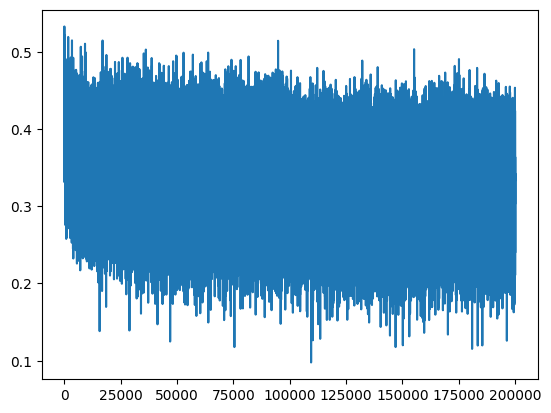

In [10]:
plt.plot(lossi)

In [12]:
# Calibrate the batch norm at the end of the training

with torch.no_grad():
    # Pass the training set through
    emb = C[Xtr]
    embcat = emb.view(emb.shape[0], -1)
    # hpreact = embcat @ W1 + b1

    #measure the mean/std over the entire training set
    bnmean = hpreact.mean(0 ,keepdim=True)
    bnstd = hpreact.std(0 ,keepdim=True)

    

`bnmean` stores the calibrated mean of the hidden pre-activations over the entire training set.

`bnbias` is the learned batch-norm bias term used to shift the normalized activations.

In evaluation:
- subtract `bnmean` from `hpreact`
- divide by `bnstd`
- scale by `bngain`
- add `bnbias`

This ensures the same normalization used during training is applied at inference time, with `bnbias` providing the final learned shift.

In [15]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
    x,y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    emb = C[x]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 #+ b1
    hpreact = bngain * (hpreact - bnmean_running)/ bnstd_running + bnbias
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')
    

train 2.0674145221710205
val 2.1056838035583496
